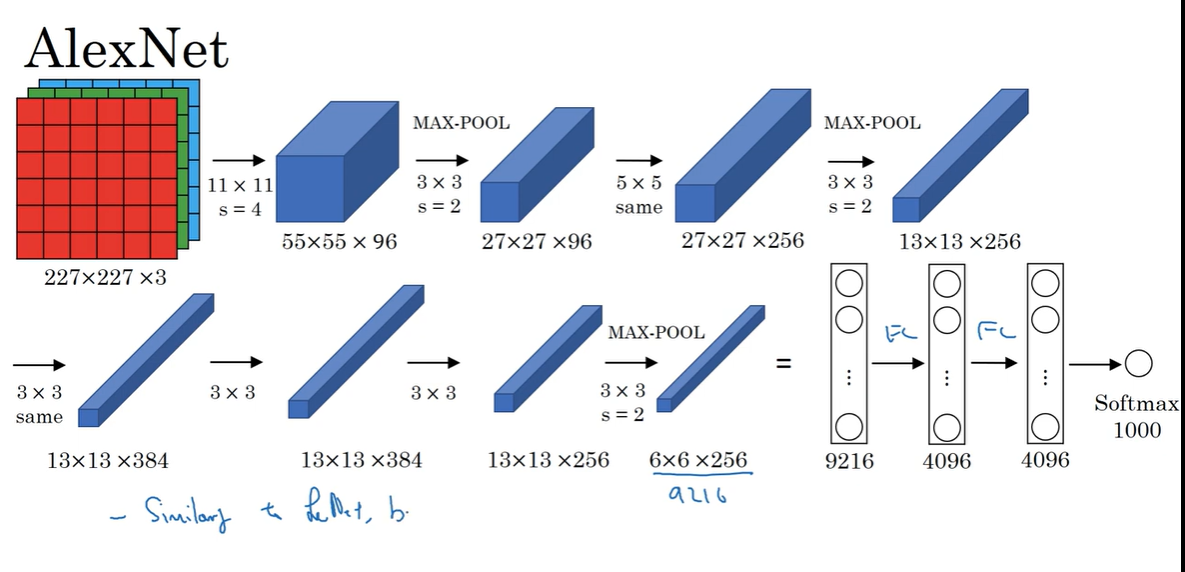



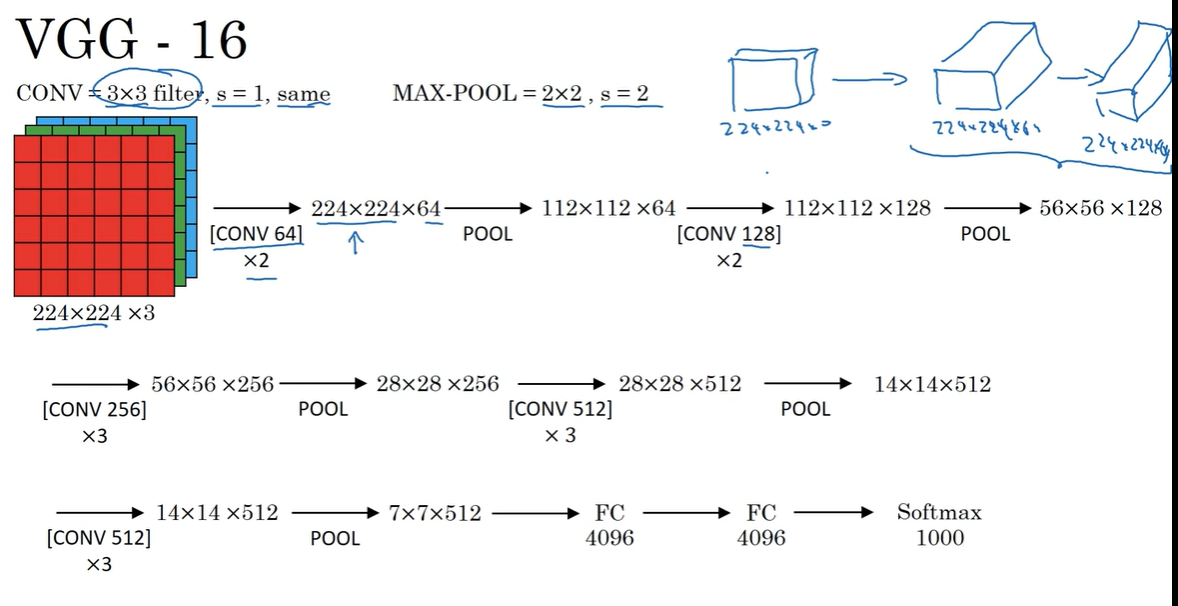



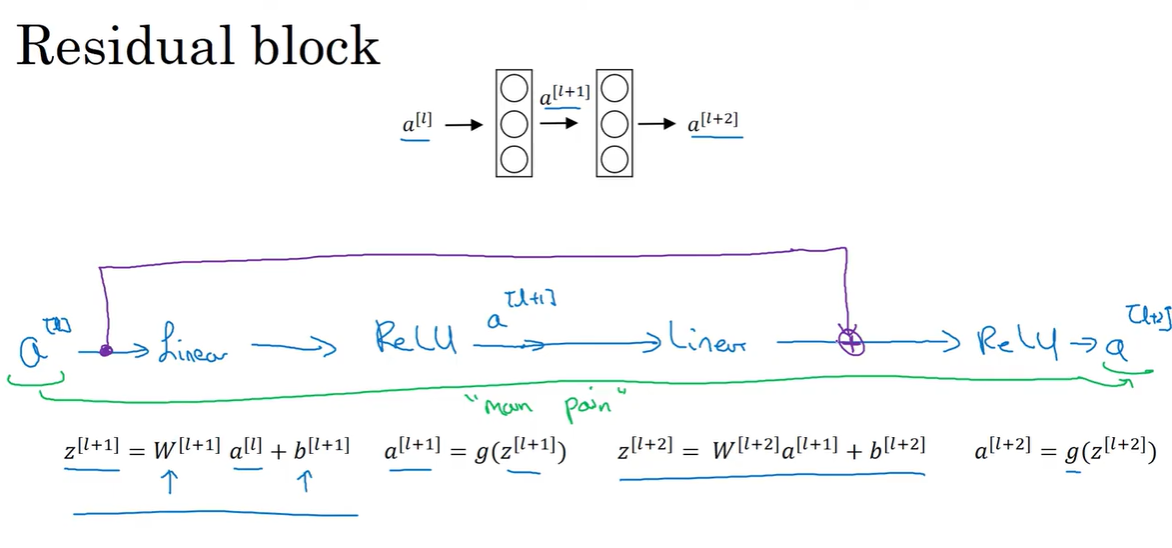




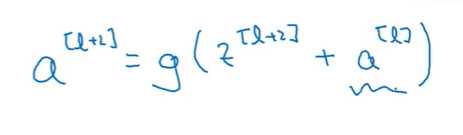

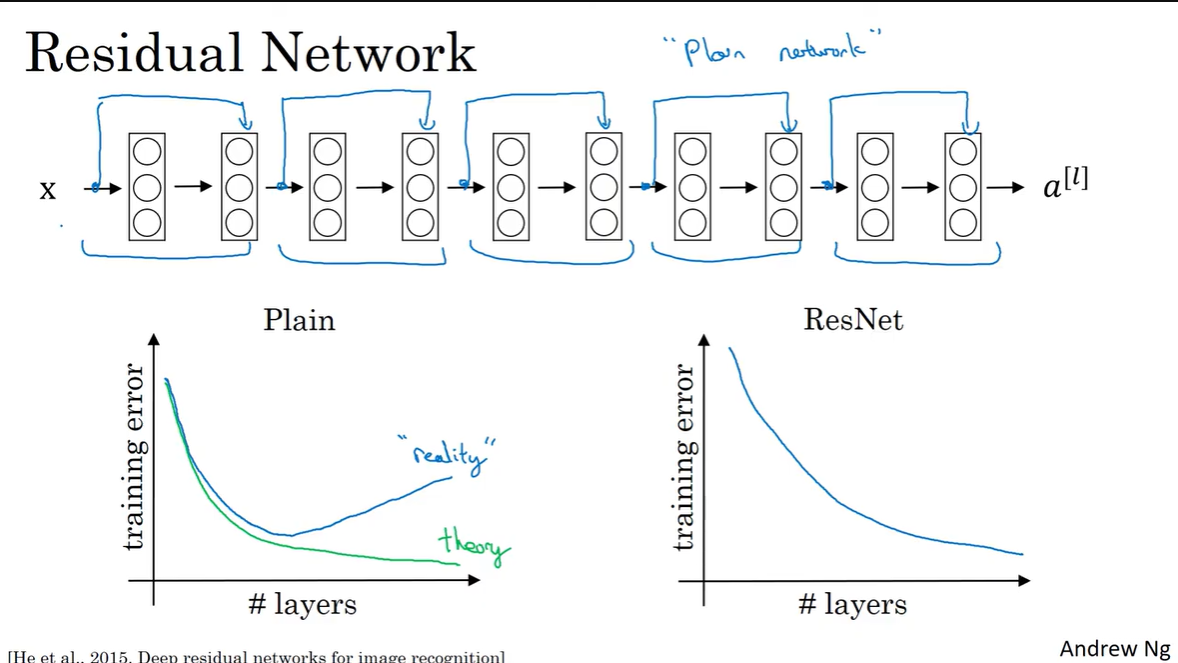

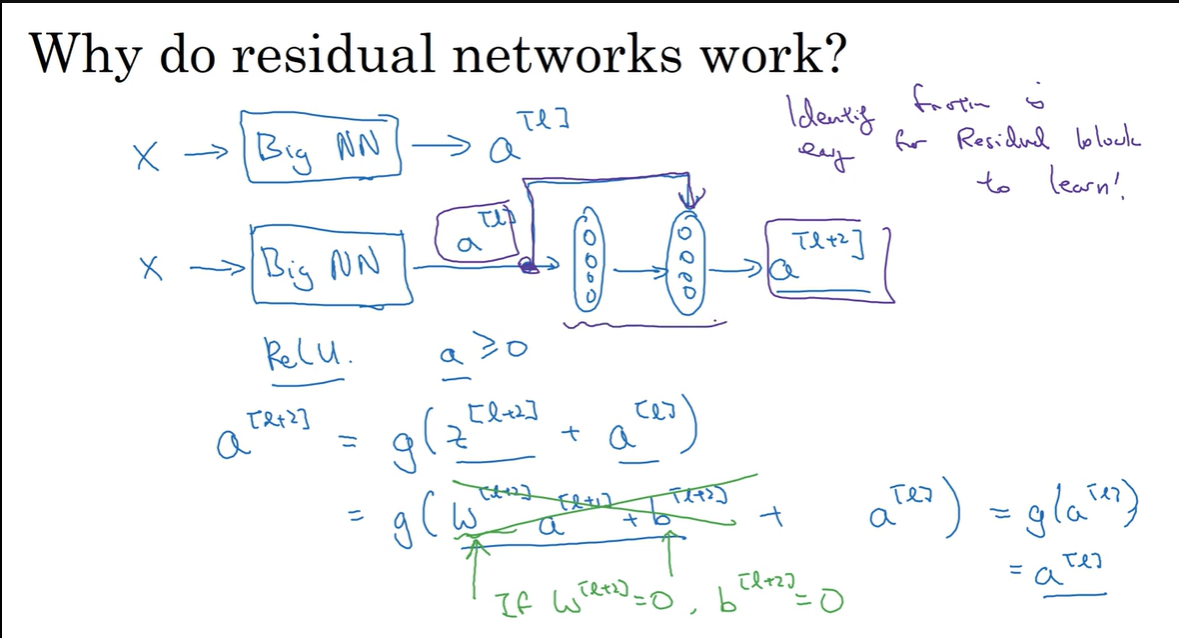

**make sure dimensions match** , if not, add an extra matrix to match dimensions.

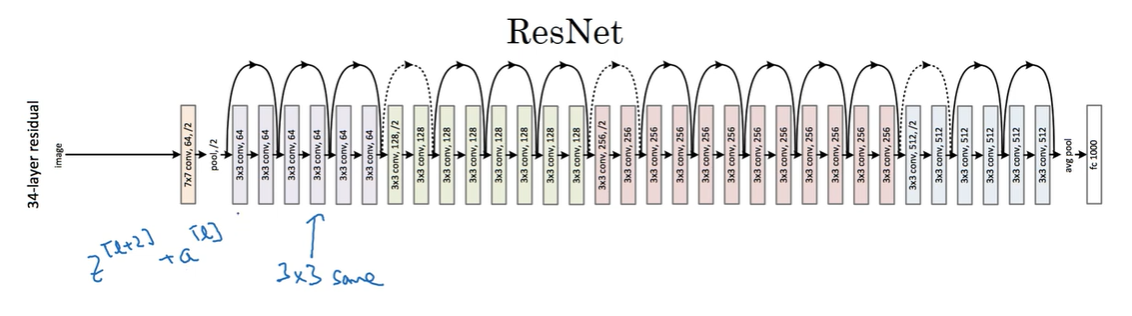

# 1x1 convolutions

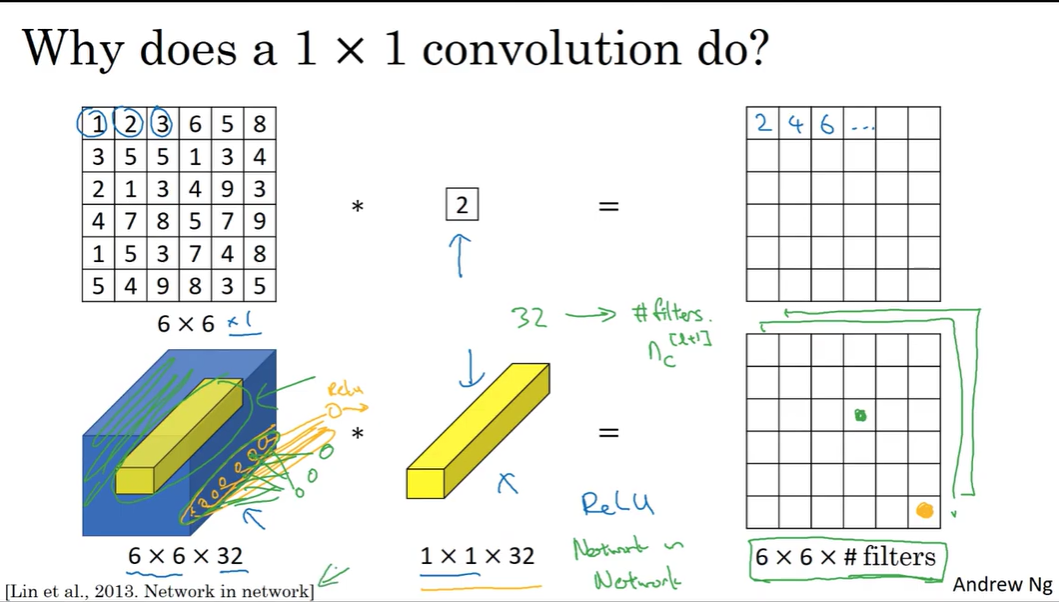

Allows you to change the number of channels in the output without changing the spatial dimensions. Analogous to max pool changing the height and width of the output without changing the number of channels. 

# inception layer

Why choose, why not use all of them? 1x1, 3x3, 5x5, max pool (weird because padding so much such that the output is the same size as the input).

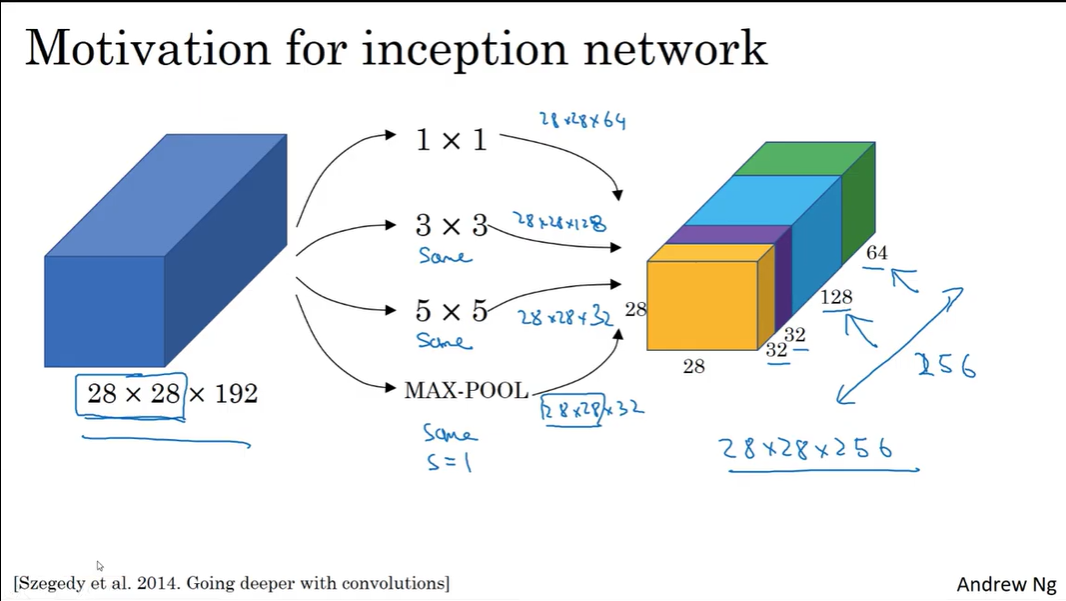

But the 1x1 convolution is used to reduce the number of channels before the 3x3 and 5x5 convolutions, which reduces the computational cost.
Let us estimate what the computational cost is for just 5x5 normally.

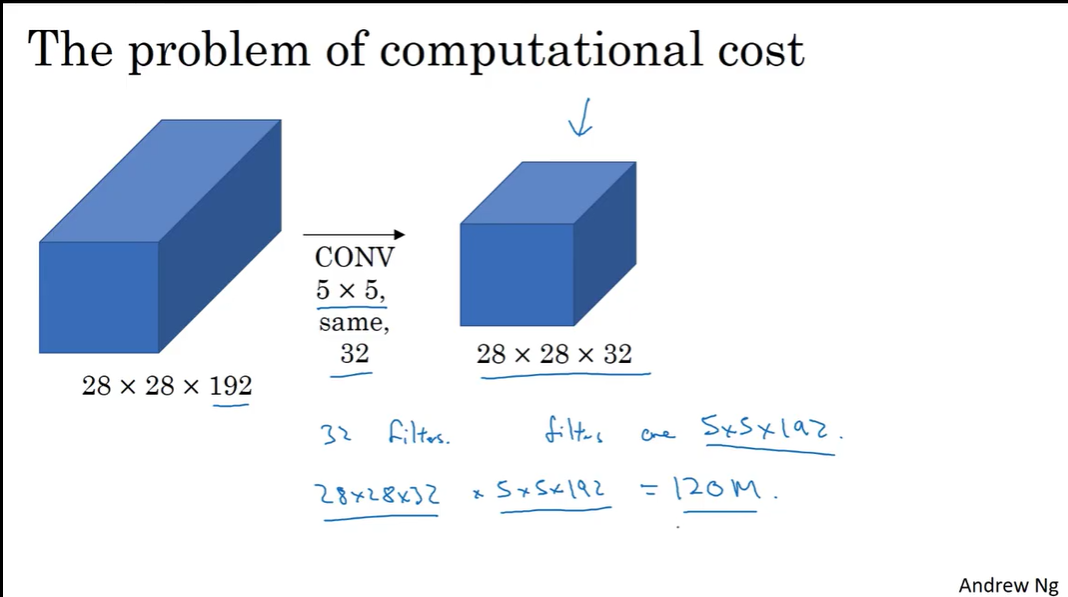

12 million parameters for just the 5x5 convolution. But if we use a 1x1 convolution to reduce the number of channels before the 5x5 convolution, we can reduce the number of parameters significantly.


----

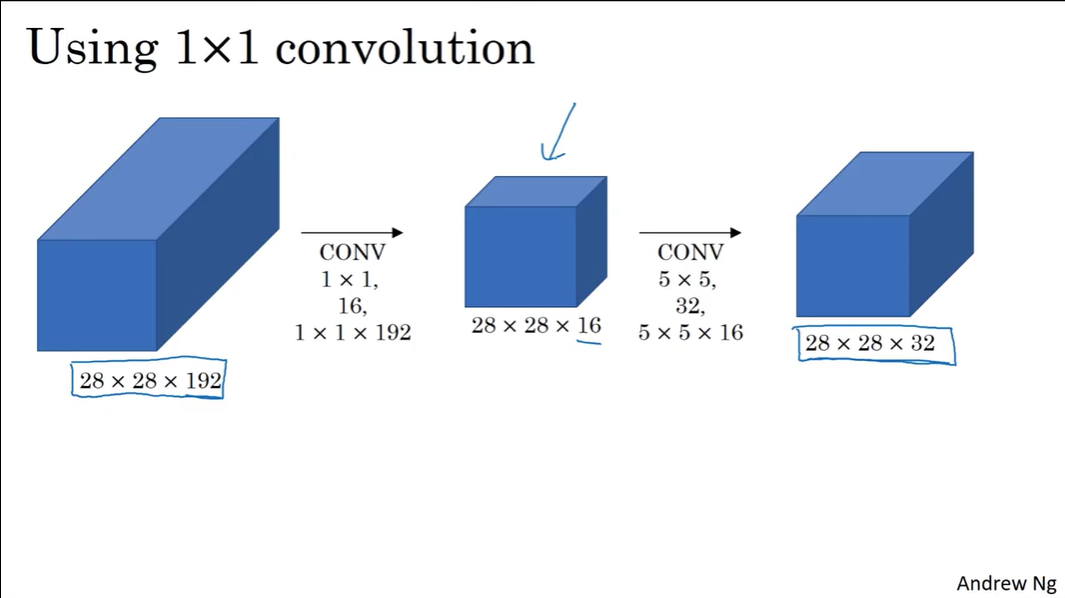

notice same input and output dimensions. The 1x1 convolution is used to reduce the number of channels before the 3x3 and 5x5 convolutions, which reduces the computational cost.

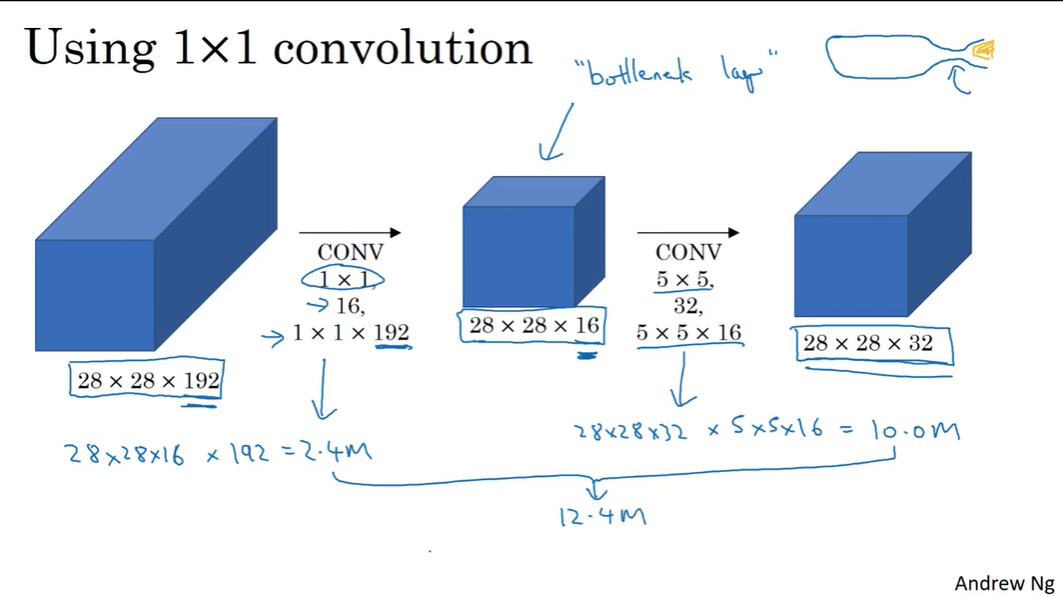

A sample inception module puts these ieas together. 

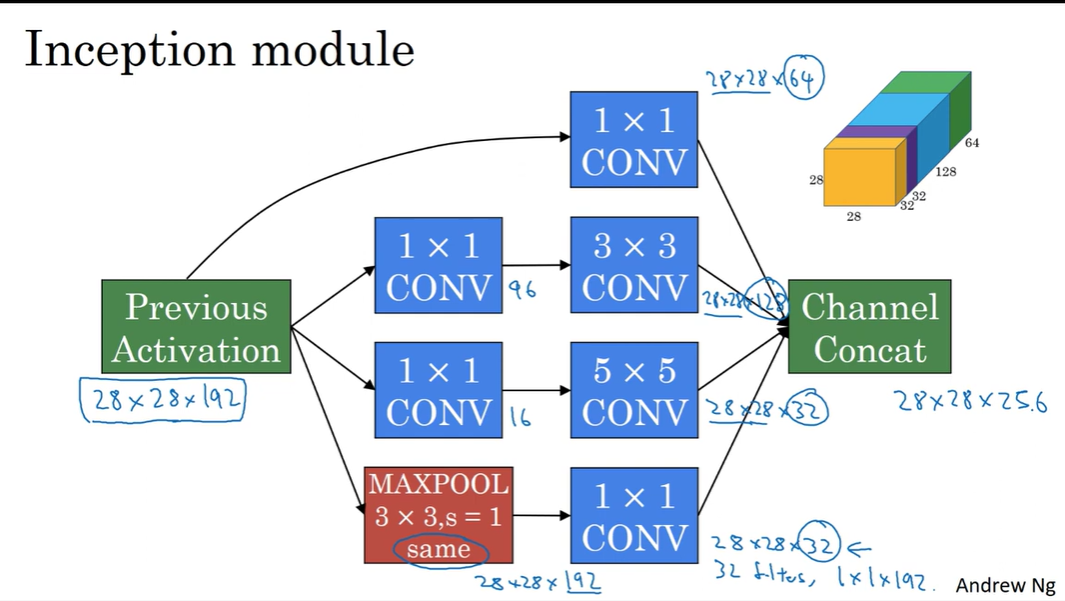

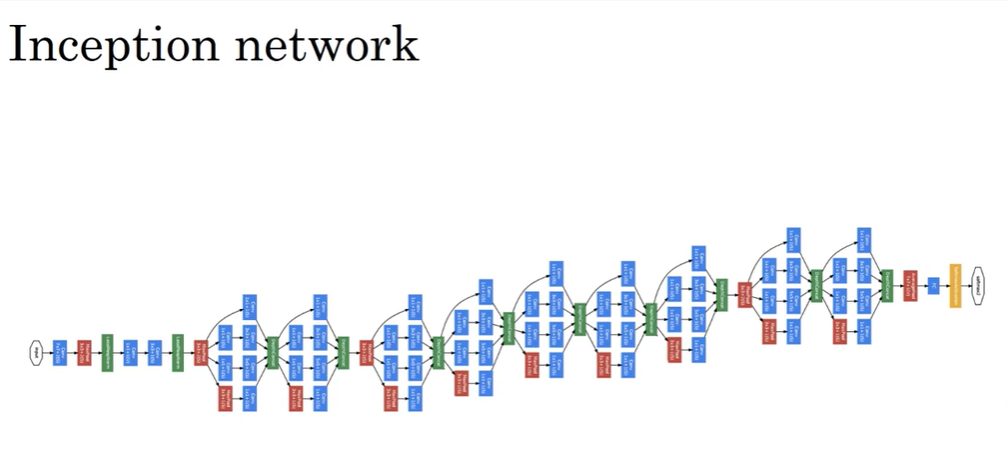

# transfer learning

see timm

# Track 2- things that apply to all of deep learning not just computer vision

## optimization algorithms etc.

## vanishing and exploding gradients

What is it? It is when the gradients become too small or too large during backpropagation, which can cause the model to not learn properly. This can happen when the weights are initialized poorly or when the learning rate is too high. or very close to optimized state as in that case, the gradients will be very small and the model will not learn.

# weight initialization

critical for ensuring that the gradients do not vanish or explode during training. Common initialization methods include Xavier/Glorot initialization and He initialization.
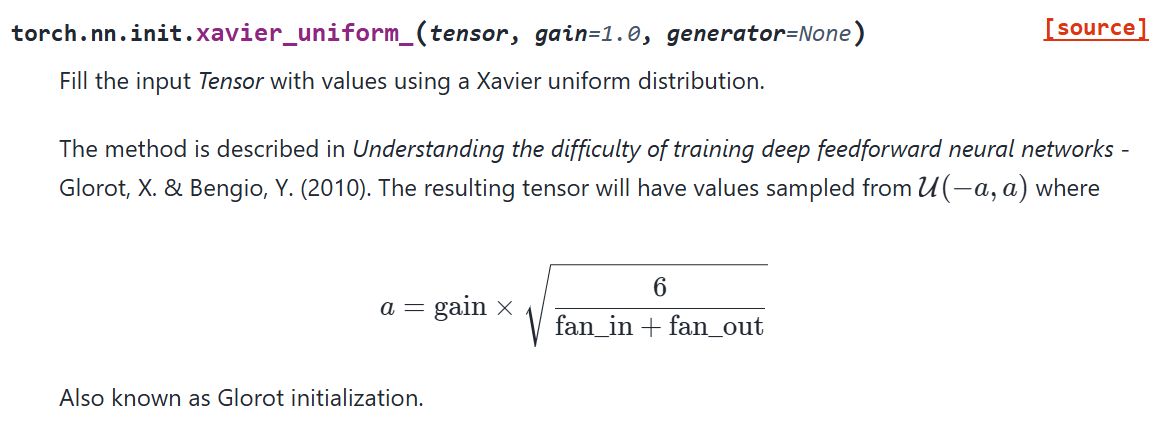

Xavier initailzation:

$W \sim \mathcal{U}\left(-\frac{\sqrt{6}}{\sqrt{n_{in} + n_{out}}}, \frac{\sqrt{6}}{\sqrt{n_{in} + n_{out}}}\right) $

Explanation of the equation: The weights are initialized from a uniform distribution between -sqrt(6)/sqrt(n_in + n_out) and sqrt(6)/sqrt(n_in + n_out), where n_in is the number of input units in the weight tensor and n_out is the number of output units. U is the uniform distribution. The idea is to keep the variance of the activations and gradients roughly the same across layers.

Kaiming He initialization:

$W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right) $

Explanation of the equation: The weights are initialized from a normal distribution with mean 0 and variance 2/n_in, where n_in is the number of input units in the weight tensor. N is the normal distribution. This initialization is particularly suited for layers with ReLU activations. N stands for normal distribution. The idea is to keep the variance of the activations and gradients roughly the same across layers.

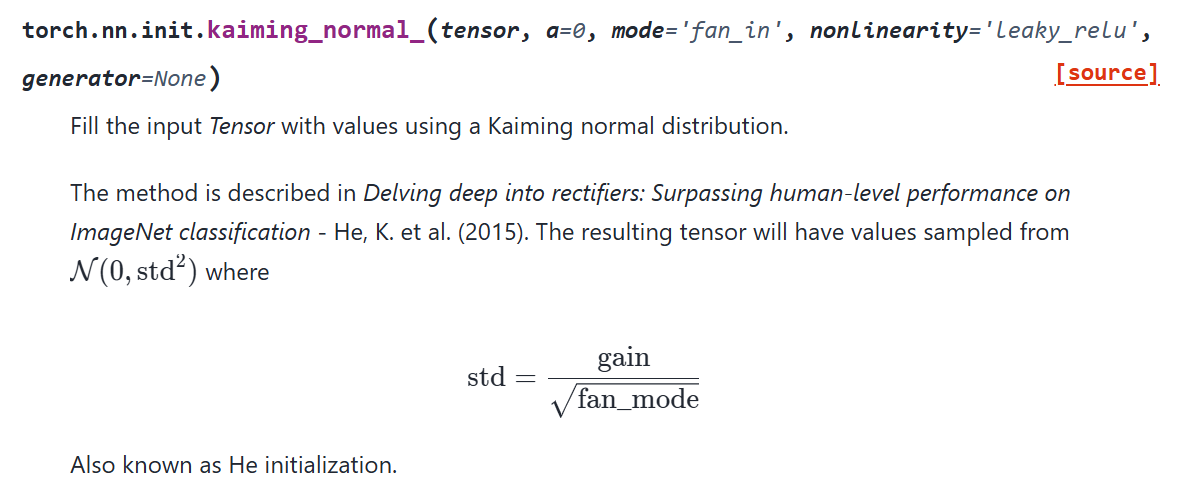

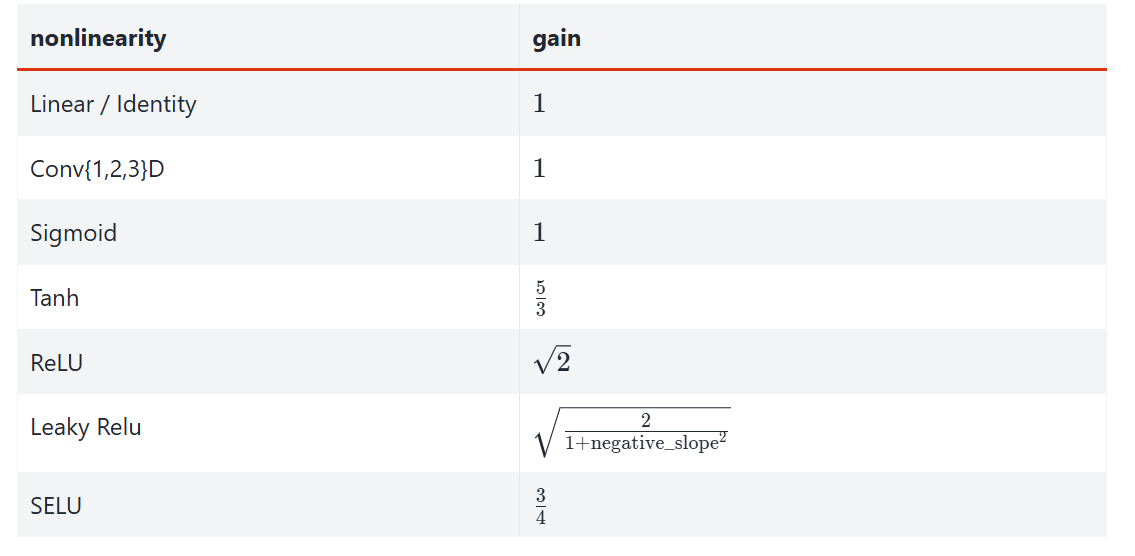

# Exponentially Weighted Moving Average (EWMA)

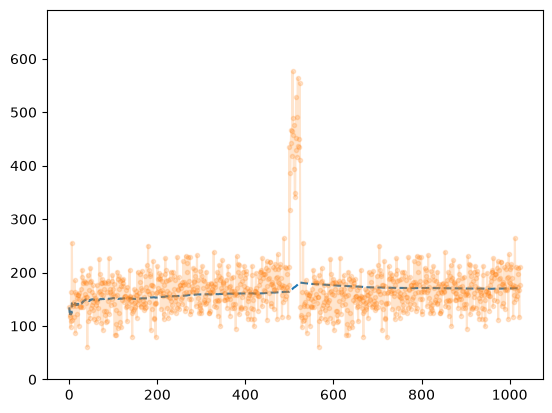

In [5]:
import numpy as np
import matplotlib.pyplot as plt
ser = 0.05*np.arange(500)+np.random.normal(size=500, loc = 150, scale = 30)
disturbance = np.random.normal(size=25, loc = 450, scale = 60)
 
# append them
ser = np.concatenate((ser, disturbance, ser))
ewm_value = 0  # Initial state
lambda_ = 0.999
ewm_ser = []
bias_correction = True # Set to True to apply bias correction
for i in range(len(ser)):
    ewm_value = lambda_ * ewm_value + (1-lambda_) * ser[i]
    if bias_correction:
        ewm_value_hat = ewm_value / (1 - lambda_**(i+1))  # Bias correction
    else:
        ewm_value_hat = ewm_value
    ewm_ser.append(ewm_value_hat)
 
plt.plot(ewm_ser, "--", markersize=3)
plt.plot(ser, "-o", markersize=3, alpha=0.2)
plt.ylim(0, 1.2*max(ser))
plt.show()


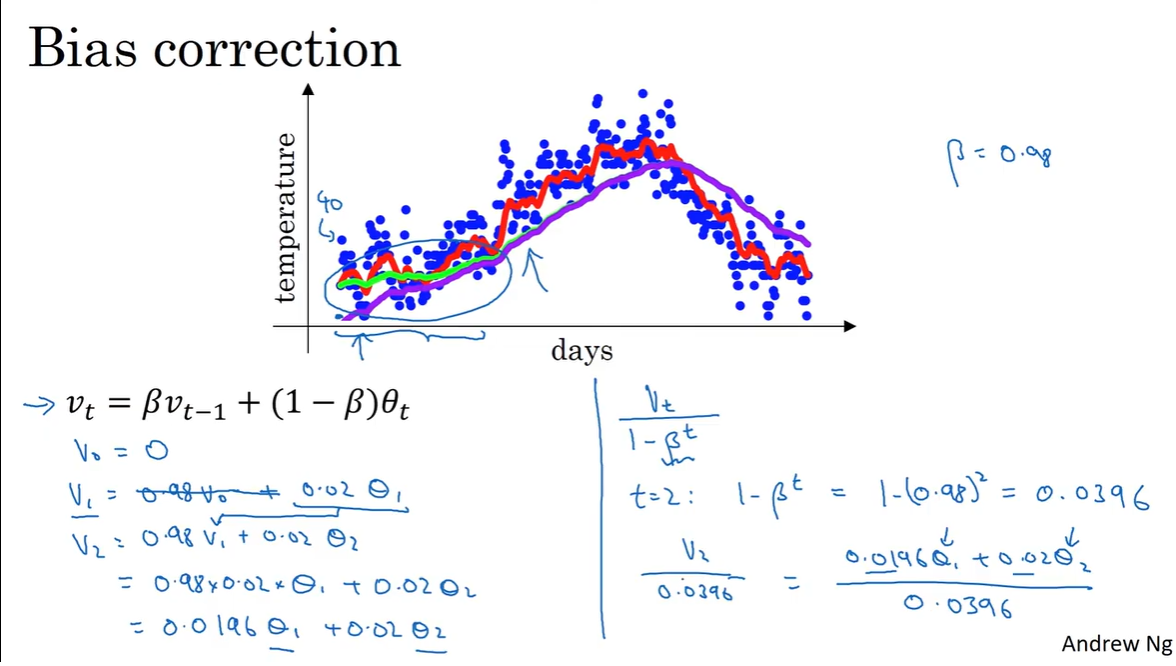

# gradient descent with momentum

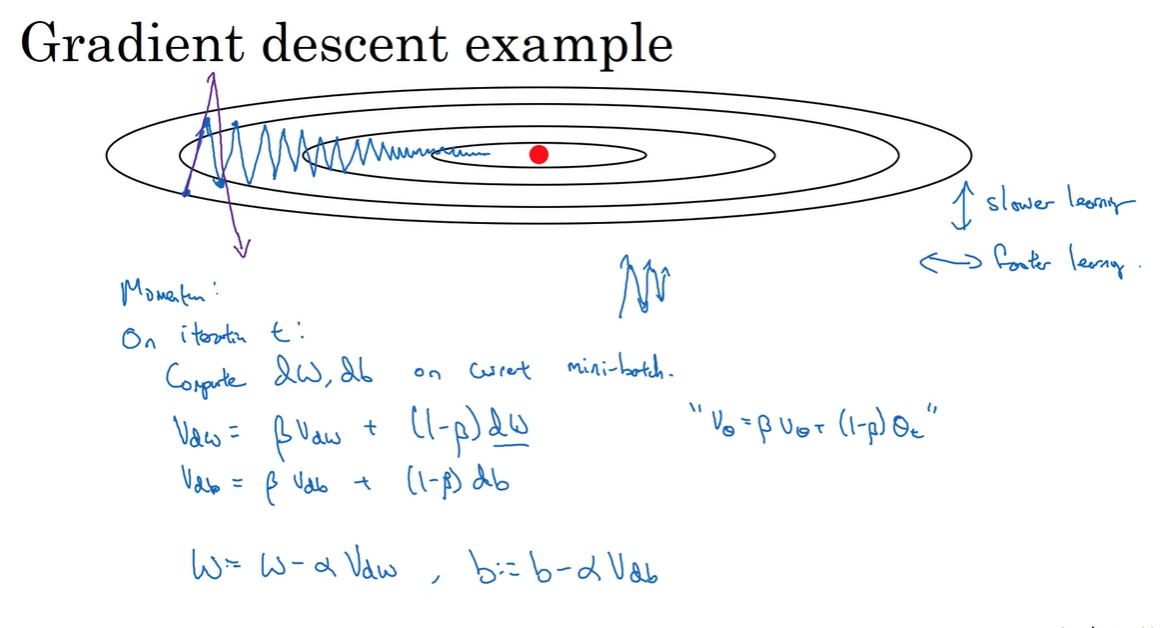

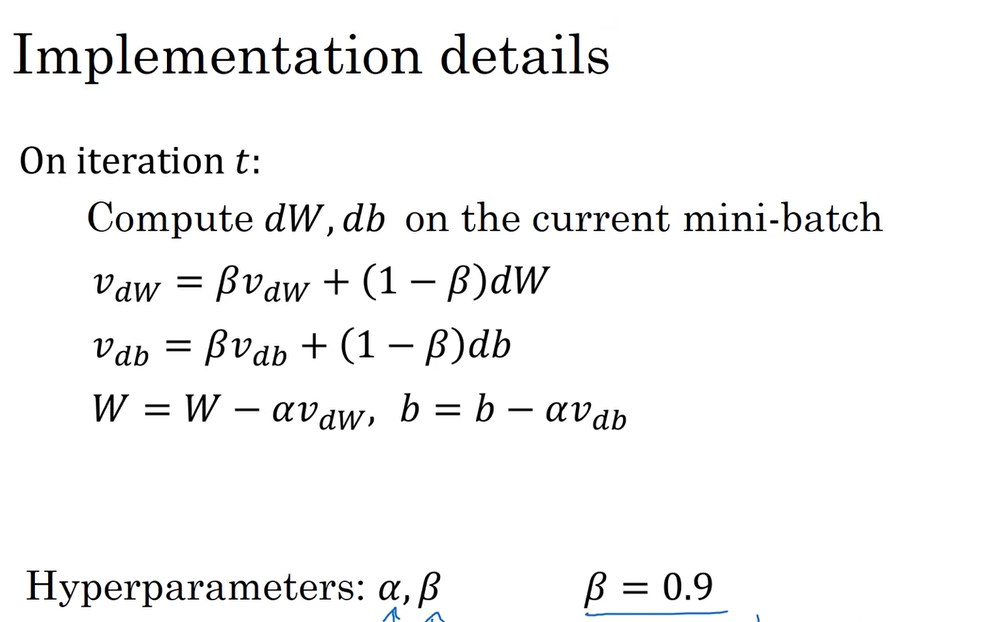

# RMS prop

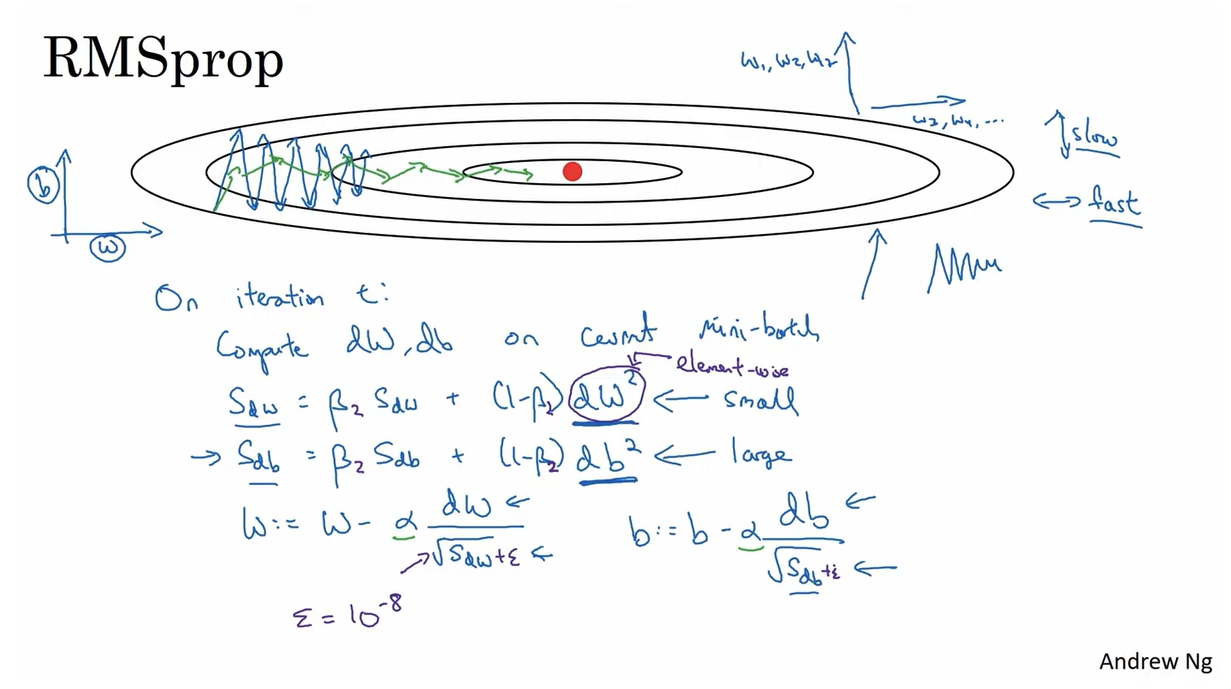

# Adam 
put RMS prop and momentum together.

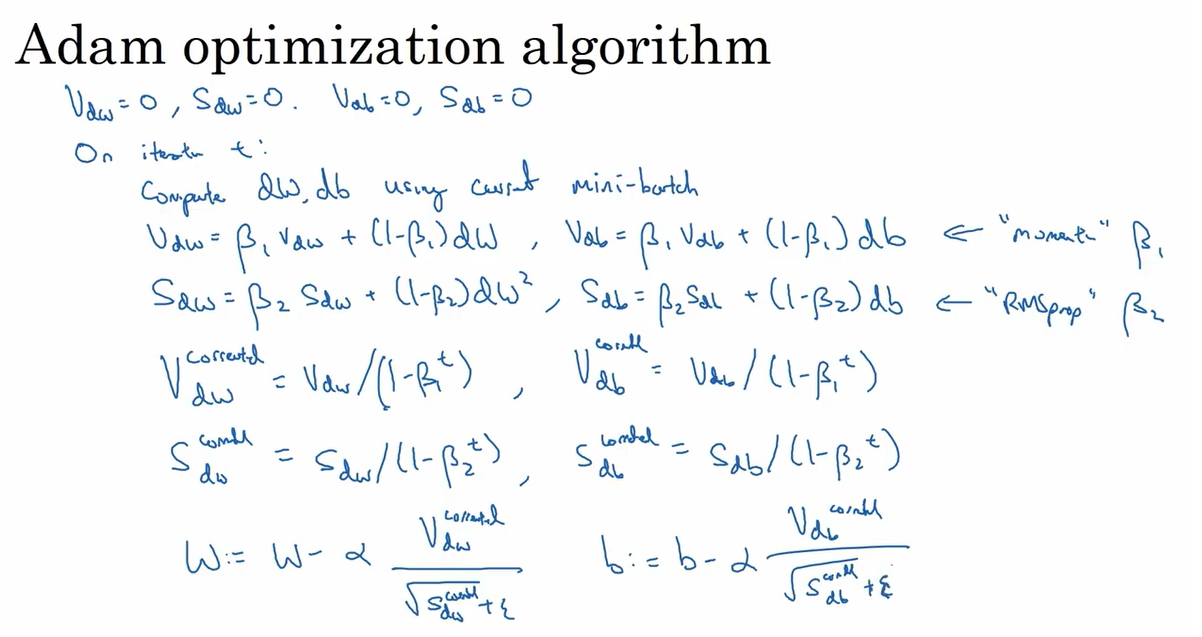


## mathematical algorithm for Adam
$ V_dw = 0, Sdw = 0, V_db = 0, Sdb = 0, \beta_1 = 0.9, \beta_2 = 0.999, \epsilon = 10^{-8} $

$ V_dw = \beta_1 V_dw + (1 - \beta_1) dW $

$ S_dw = \beta_2 S_dw + (1 - \beta_2) dW^2 $

$ V_dw^{corrected} = \frac{V_dw}{1 - \beta_1^t} $

$ S_dw^{corrected} = \frac{S_dw}{1 - \beta_2^t} $

$ W = W - \alpha \frac{V_dw^{corrected}}{\sqrt{S_dw^{corrected}} + \epsilon} $

Similarly for db.

$V_db = \beta_1 V_db + (1 - \beta_1) db $

$S_db = \beta_2 S_db + (1 - \beta_2) db^2 $

$V_db^{corrected} = \frac{V_db}{1 - \beta_1^t} $

$S_db^{corrected} = \frac{S_db}{1 - \beta_2^t} $

$ b = b - \alpha \frac{V_db^{corrected}}{\sqrt{S_db^{corrected}} + \epsilon} $

# learning rate schedulers, decay, warmup, annealing, cosine annealing, etc.


# Learning Rate Schedulers

- Gradient descent converges quickly initially, but later requires smaller steps to avoid oscillation around the minimum.
- Instead of using a fixed learning rate, gradually reduce it during training.

## Learning Rate Decay

Decrease the learning rate as training progresses.

Examples:
- Step decay
- Exponential decay
- Polynomial decay

## Warmup

Begin training with a very small learning rate and gradually increase it.

Useful because:
- prevents unstable updates during the first few iterations
- especially important for very deep networks and Transformers

Typical schedule:

```
small LR ---> target LR
```

## Annealing

Gradually reduce the learning rate toward zero.

Intuition:
- Large steps while exploring.
- Small steps while converging.

## Cosine Annealing

Instead of monotonically decreasing the learning rate, vary it according to a cosine curve.

Advantages:
- smooth decay
- often converges better than abrupt step reductions

$$
\eta_t = \eta_{\min} +
\frac{1}{2}(\eta_{\max}-\eta_{\min})
\left(1+\cos\frac{\pi t}{T}\right)
$$

Learning rate:

```
LR
│\
│ \
│  \
│   \______
└──────────── Epochs
```

## Cosine Annealing with Warm Restarts (SGDR)

Instead of continually decreasing the learning rate, periodically increase it again.

Motivation:
- escape shallow local minima
- encourage exploration
- often improves the final solution

```
LR
│\/\    /\
│  \   /  \
│   \_/    \__
└────────────── Epochs
```

## Common Practice

Typical recipe:

- Warmup
- Constant LR (briefly)
- Cosine Annealing
- Train until convergence

Modern optimizers and frameworks usually implement these schedulers directly.


## Common Learning Rate Schedulers

PyTorch provides several built-in schedulers:

- `StepLR` – reduce LR every *N* epochs.
- `MultiStepLR` – reduce LR at specific milestones.
- `ExponentialLR` – exponential decay.
- `LinearLR` – linear warmup / decay.
- `PolynomialLR` – polynomial decay.
- `ConstantLR` – hold LR constant for an initial period.
- `SequentialLR` – combine multiple schedulers (e.g. warmup → cosine).
- `CosineAnnealingLR` – cosine annealing.
- `CosineAnnealingWarmRestarts` – cosine annealing with periodic restarts.
- `OneCycleLR` – increase LR, then decrease; often an excellent default.
- `ReduceLROnPlateau` – reduce LR automatically when validation loss stops improving.

## Common Practice

Typical modern training recipe:

```
Warmup
   ↓
Constant / Peak LR
   ↓
Cosine Annealing
   ↓
Train until convergence
```

or simply use **OneCycleLR**, which combines warmup and annealing into a single schedule.

Learning rate scheduling is now considered standard practice when training deep neural networks.






# Batch Normalization

## Motivation

Deep networks are difficult to train because the distribution of activations changes during training.

Effects:
- Vanishing / exploding activations
- Unstable gradients
- Slower convergence
- Requires careful initialization

Batch Normalization normalizes the activations of each mini-batch, making optimization easier.

---

## Idea

Instead of passing

$$
x
$$

through the activation,

normalize it first.

For a mini-batch,

$$
\mu_B = \frac{1}{m}\sum_i x_i
$$

$$
\sigma_B^2 = \frac{1}{m}\sum_i (x_i-\mu_B)^2
$$

Normalize:

$$
\hat{x}_i=\frac{x_i-\mu_B}
{\sqrt{\sigma_B^2+\epsilon}}
$$

Then allow the network to learn the appropriate scale and shift:

$$
y_i=\gamma\hat{x}_i+\beta
$$

where

- $\gamma$ : learnable scale
- $\beta$ : learnable bias

---

## Why not just normalize?

A fixed normalization may remove useful information.

The learnable parameters

$$
\gamma,\;\beta
$$

allow the network to recover any distribution if required.

If BatchNorm is not useful,

$$
\gamma=\sigma,\qquad
\beta=\mu
$$

approximately recovers the original activations.

---



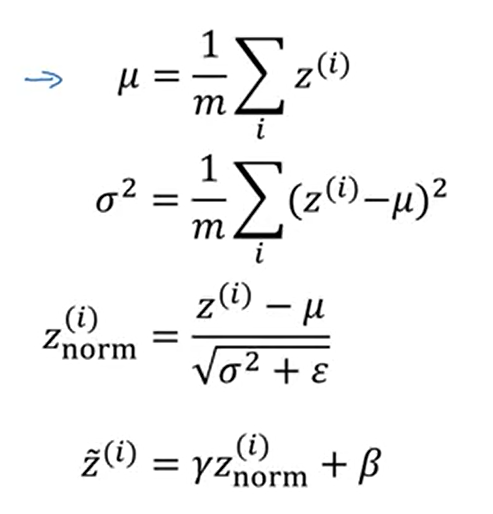


## Training

For **each mini-batch**

1. Compute batch mean.
2. Compute batch variance.
3. Normalize activations.
4. Apply learned scale and shift.
5. Update running estimates of mean and variance.

```
Mini Batch
     │
Compute μ, σ²
     │
Normalize
     │
γx + β
     │
Activation
```

---

## Inference (Test Time)

**No batch statistics are computed.**

Instead, use the running averages accumulated during training.

$$
\mu_{running}
$$

$$
\sigma^2_{running}
$$

Reason:

- inference may have batch size = 1
- predictions should be deterministic
- output should not depend on other samples in the batch

---

## Important

BatchNorm is one of the few layers whose behaviour is **different** during training and inference.

Training:

```
Current Mini-Batch
        │
Compute μ, σ²
```

Inference:

```
Running Mean
Running Variance
        │
Normalize
```

Hence

```python
model.train()
```

and

```python
model.eval()
```

produce different behaviour.

---

## Benefits

- Faster convergence
- More stable gradients
- Less sensitive to initialization
- Allows larger learning rates
- Mild regularization effect (batch statistics introduce noise)

---

## Notes

- Usually applied **before** the activation function.
- Common after convolutional and fully connected layers.
- Works best with reasonably large batch sizes.
- Less effective for very small batches (LayerNorm, GroupNorm are alternatives).

### Precision, Recall, F1 Score, and Why Accuracy is Not a Good Metric for Imbalanced Datasets

Suppose you have a dataset containing **1000 samples**, where **950 belong to class A** and **50 belong to class B**.

Now imagine a model that simply predicts **every sample as class A**.

The resulting confusion matrix is:

| Actual \ Predicted | Class A | Class B |
| ------------------ | ------: | ------: |
| **Class A**        |     950 |       0 |
| **Class B**        |      50 |       0 |

The model achieves an **accuracy of 95%**:

$$
\text{Accuracy} = \frac{950}{1000} = 0.95
$$

At first glance this appears to be an excellent model. However, it has **completely failed to identify any samples belonging to class B**, the minority class. This illustrates why **accuracy alone can be a misleading metric when the classes are imbalanced.**

---

#### Precision

Precision answers the question:

> **Of all the samples that the model predicted as positive, how many were actually positive?**

It is defined as

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

where:

* **TP (True Positives):** Positive samples correctly predicted as positive.
* **FP (False Positives):** Negative samples incorrectly predicted as positive.

For the previous example, consider **class B** as the positive class.

Since the model never predicts class B,

* $TP = 0$
* $FP = 0$

Therefore,

$$
\text{Precision} = \frac{0}{0+0}
$$

which is mathematically **undefined**. In practice, most machine learning libraries report the precision as **0**, since the model never attempts to identify class B.

---

#### Recall

Recall answers the question:

> **Of all the actual positive samples, how many did the model successfully identify?**

It is defined as

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

where:

* **FN (False Negatives):** Positive samples incorrectly predicted as negative.

Again considering class B,

* $TP = 0$
* $FN = 50$

Therefore,

$$
\text{Recall} = \frac{0}{0+50} = 0.
$$

The model completely fails to detect the minority class.

---

#### A More Realistic Example

Suppose the model predicts **100 samples as class B**.

Out of these:

* **40 are actually class B** (True Positives)
* **60 are actually class A** (False Positives)

Since there are 50 actual class B samples, the remaining

* **10 class B samples were missed** (False Negatives).

The confusion matrix becomes:

| Actual \ Predicted | Class A | Class B |
| ------------------ | ------: | ------: |
| **Class A**        |     890 |      60 |
| **Class B**        |      10 |      40 |

The precision is

$$
\text{Precision} = \frac{40}{40+60} = 0.4.
$$

The recall is

$$
\text{Recall} = \frac{40}{40+10} = 0.8.
$$

This model identifies **80% of the actual class B samples**, but only **40% of its class B predictions are correct**. In other words, it finds most of the minority-class samples, but at the cost of producing many false alarms.

---

#### F1 Score

Precision and recall often pull in opposite directions. Increasing recall may require making more positive predictions, which can reduce precision. Conversely, increasing precision may require being more conservative, which can reduce recall.

The **F1 score** combines precision and recall into a single metric using their harmonic mean:

$$
F_1 = \frac{2 \times \text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

For the previous example,

$$
F_1 = \frac{2 \times 0.4 \times 0.8}{0.4 + 0.8}
= \frac{0.64}{1.2}
\approx 0.53.
$$

A high F1 score requires **both** precision and recall to be high. If either one is poor, the F1 score will also be low, making it a useful metric for evaluating models on imbalanced datasets.
